In [1]:
import pandas as pd
from glob import glob
import os
import json

In [9]:
dfs = []
json_paths_glob = os.path.join('logs', 'finetune_cpb_20250820', '*', '*', '*', '*', '*', '*', '*.json')
# Use glob to find all JSON files in the specified
# for json_path in glob('./logs/finetune_cpb_20250820/*/*/*/*/*/*/*.json'):
for json_path in glob(json_paths_glob):
    
    path_parts = json_path.split(os.sep)
    model = path_parts[2]
    weights = path_parts[3]
    method = path_parts[-5]
    n_train = int(path_parts[-4].split('_')[-1])
    rep = int(path_parts[-3].split('_')[-1])
    fold = int(path_parts[-2].split('_')[-1])
    
    # if model == 'unet' or weights == 'none':
        # continue
    
    # print(f'Processing {method} rep {rep} fold {fold} with {n_train} training samples')
    metrics_data = json.load(open(json_path, 'r'))
    metrics_data['model'] = model
    metrics_data['weights'] = weights
    metrics_data['method'] = method
    metrics_data['n_train'] = n_train
    metrics_data['rep'] = rep
    metrics_data['fold'] = fold
    dfs.append(pd.DataFrame(metrics_data, index=[0]))

metrics_df = pd.concat(dfs, ignore_index=True)
display(metrics_df)

,accuracy,f1_score,precision,recall,jaccard,kappa,macro_f1_score,macro_precision,macro_recall,macro_jaccard,weighted_f1_score,weighted_precision,weighted_recall,weighted_jaccard,model,weights,method,n_train,rep,fold
0,0.799766,0.794376,0.801128,0.799766,0.688298,0.879217,0.492549,0.601150,0.491427,0.381148,0.794376,0.801128,0.799766,0.688298,deeplabv3plus,none,semss,250,0,1
1,0.818591,0.806523,0.805809,0.818591,0.705624,0.891824,0.538540,0.631617,0.523536,0.423227,0.806523,0.805809,0.818591,0.705624,deeplabv3plus,none,semss,250,0,2
2,0.823092,0.814340,0.814667,0.823092,0.714415,0.893741,0.554802,0.630005,0.535366,0.432958,0.814340,0.814667,0.823092,0.714415,deeplabv3plus,none,semss,250,0,3
3,0.800182,0.789364,0.792146,0.800182,0.682747,0.880718,0.489660,0.559125,0.484086,0.379805,0.789364,0.792146,0.800182,0.682747,deeplabv3plus,none,semss,250,0,4
4,0.802865,0.776694,0.795119,0.802865,0.682551,0.882930,0.430827,0.573684,0.448404,0.346607,0.776694,0.795119,0.802865,0.682551,deeplabv3plus,none,semss,250,1,2
5,0.827548,0.819015,0.817815,0.827548,0.721422,0.896431,0.552683,0.648978,0.538602,0.436802,0.819015,0.817815,0.827548,0.721422,deeplabv3plus,none,semss,500,0,1
6,0.828749,0.822437,0.821698,0.828749,0.723561,0.896908,0.578875,0.636294,0.558786,0.452772,0.822437,0.821698,0.828749,0.723561,deeplabv3plus,none,semss,500,0,2
7,0.823124,0.813592,0.811216,0.823124,0.715062,0.894151,0.543764,0.636554,0.519352,0.422652,0.813592,0.811216,0.823124,0.715062,deeplabv3plus,none,semss,500,0,3
8,0.833680,0.825653,0.823218,0.833680,0.728393,0.900180,0.582381,0.655298,0.559485,0.458111,0.825653,0.823218,0.833680,0.728393,deeplabv3plus,none,semss,500,0,4
9,0.814076,0.801961,0.805864,0.814076,0.700681,0.888981,0.509903,0.634524,0.500997,0.399905,0.801961,0.805864,0.814076,0.700681,deeplabv3plus,none,semss,500,0,5


In [10]:
# metrics_df.loc[(metrics_df.weights == 'none') & (metrics_df.rep <= 1)].groupby(['model', 'weights', 'method', 'n_train']).max().sort_values(by='macro_jaccard', ascending=False)
metrics_df.loc[(metrics_df.rep <= 3)].groupby(['model', 'weights', 'method', 'n_train']).mean().sort_values(by='macro_jaccard', ascending=False)

accuracy  f1_score  precision    recall  \
model         weights method n_train                                            
deeplabv3plus none    semss  750      0.834752  0.828207   0.826114  0.834752   
                             500      0.825593  0.816715   0.816049  0.825593   
                      srs    500      0.825837  0.813817   0.814000  0.825837   
                      sss    750      0.826001  0.813606   0.815155  0.826001   
                      srs    750      0.820614  0.806466   0.808808  0.820614   
                      sss    500      0.818559  0.804457   0.805611  0.818559   
                      semss  250      0.808899  0.796259   0.801774  0.808899   
                      srs    250      0.806005  0.786642   0.788412  0.806005   
                      sss    250      0.796408  0.773364   0.773364  0.796408   

                                       jaccard     kappa  macro_f1_score  \
model         weights method n_train                                       
deeplabv3plus none    semss  750      0.731807  0.900543        0.595899   
                             500      0.717922  0.895421        0.554617   
                      srs    500      0.715139  0.896202        0.534841   
                      sss    750      0.715185  0.896359        0.534822   
                      srs    750      0.706227  0.893474        0.506672   
                      sss    500      0.704763  0.892113        0.507537   
                      semss  250      0.694727  0.885686        0.501276   
                      srs    250      0.683662  0.885623        0.471752   
                      sss    250      0.668188  0.880652        0.449905   

                                      macro_precision  macro_recall  \
model         weights method n_train                                  
deeplabv3plus none    semss  750             0.667597      0.570032   
                             500             0.639215      0.536472   
                      srs    500             0.641635      0.515681   
                      sss    750             0.658198      0.510933   
                      srs    750             0.648499      0.489085   
                      sss    500             0.609579      0.490402   
                      semss  250             0.599116      0.496564   
                      srs    250             0.582375      0.458896   
                      sss    250             0.521599      0.432671   

                                      macro_jaccard  weighted_f1_score  \
model         weights method n_train                                     
deeplabv3plus none    semss  750           0.469039           0.828207   
                             500           0.434799           0.816715   
                      srs    500           0.422747           0.813817   
                      sss    750           0.418323           0.813606   
                      srs    750           0.399973           0.806466   
                      sss    500           0.397543           0.804457   
                      semss  250           0.392749           0.796259   
                      srs    250           0.371752           0.786642   
                      sss    250           0.349948           0.773364   

                                      weighted_precision  weighted_recall  \
model         weights method n_train                                        
deeplabv3plus none    semss  750                0.826114         0.834752   
                             500                0.816049         0.825593   
                      srs    500                0.814000         0.825837   
                      sss    750                0.815155         0.826001   
                      srs    750                0.808808         0.820614   
                      sss    500                0.805611         0.818559   
                      semss  250                0.801774         0.808899   
                   

In [11]:
metrics_df

,accuracy,f1_score,precision,recall,jaccard,kappa,macro_f1_score,macro_precision,macro_recall,macro_jaccard,weighted_f1_score,weighted_precision,weighted_recall,weighted_jaccard,model,weights,method,n_train,rep,fold
0,0.799766,0.794376,0.801128,0.799766,0.688298,0.879217,0.492549,0.601150,0.491427,0.381148,0.794376,0.801128,0.799766,0.688298,deeplabv3plus,none,semss,250,0,1
1,0.818591,0.806523,0.805809,0.818591,0.705624,0.891824,0.538540,0.631617,0.523536,0.423227,0.806523,0.805809,0.818591,0.705624,deeplabv3plus,none,semss,250,0,2
2,0.823092,0.814340,0.814667,0.823092,0.714415,0.893741,0.554802,0.630005,0.535366,0.432958,0.814340,0.814667,0.823092,0.714415,deeplabv3plus,none,semss,250,0,3
3,0.800182,0.789364,0.792146,0.800182,0.682747,0.880718,0.489660,0.559125,0.484086,0.379805,0.789364,0.792146,0.800182,0.682747,deeplabv3plus,none,semss,250,0,4
4,0.802865,0.776694,0.795119,0.802865,0.682551,0.882930,0.430827,0.573684,0.448404,0.346607,0.776694,0.795119,0.802865,0.682551,deeplabv3plus,none,semss,250,1,2
5,0.827548,0.819015,0.817815,0.827548,0.721422,0.896431,0.552683,0.648978,0.538602,0.436802,0.819015,0.817815,0.827548,0.721422,deeplabv3plus,none,semss,500,0,1
6,0.828749,0.822437,0.821698,0.828749,0.723561,0.896908,0.578875,0.636294,0.558786,0.452772,0.822437,0.821698,0.828749,0.723561,deeplabv3plus,none,semss,500,0,2
7,0.823124,0.813592,0.811216,0.823124,0.715062,0.894151,0.543764,0.636554,0.519352,0.422652,0.813592,0.811216,0.823124,0.715062,deeplabv3plus,none,semss,500,0,3
8,0.833680,0.825653,0.823218,0.833680,0.728393,0.900180,0.582381,0.655298,0.559485,0.458111,0.825653,0.823218,0.833680,0.728393,deeplabv3plus,none,semss,500,0,4
9,0.814076,0.801961,0.805864,0.814076,0.700681,0.888981,0.509903,0.634524,0.500997,0.399905,0.801961,0.805864,0.814076,0.700681,deeplabv3plus,none,semss,500,0,5


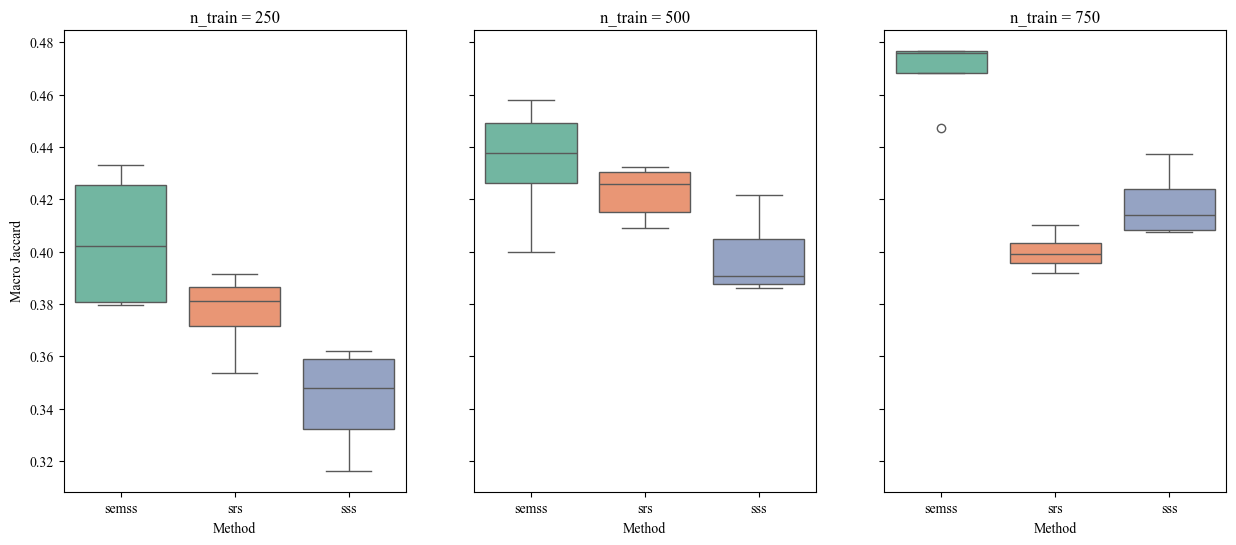

In [13]:
# create boxplot
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'

df = metrics_df.copy()
# df = df[df.weights == 'none']
df = df.loc[df.rep <= 0]
fig, ax = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
n_train_values = [250, 500, 750]
for i, n_train in enumerate(n_train_values):
    sns.boxplot(data=df[df.n_train == n_train], x='method', y='macro_jaccard', ax=ax[i], palette='Set2', hue='method', legend=False)
    ax[i].set_title(f'n_train = {n_train}')
    ax[i].set_ylabel('Macro Jaccard')
    ax[i].set_xlabel('Method')

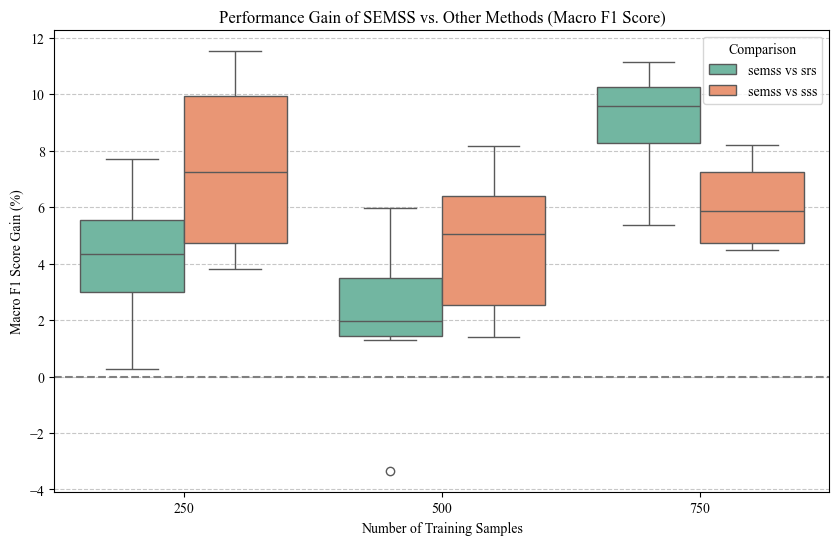

In [12]:

# Create a plot to emphasize the performance gain of SEMSS
df_pivot = df.pivot_table(index=['n_train', 'rep', 'fold'], columns='method', values='macro_f1_score').reset_index()

# Calculate the performance gain of semss over the other methods and convert to percent
df_pivot['semss_gain_vs_srs'] = (df_pivot['semss'] - df_pivot['srs']) * 100
df_pivot['semss_gain_vs_sss'] = (df_pivot['semss'] - df_pivot['sss']) * 100

# Melt the dataframe to make it suitable for plotting with seaborn
df_gain = df_pivot.melt(
    id_vars=['n_train'], 
    value_vars=['semss_gain_vs_srs', 'semss_gain_vs_sss'],
    var_name='comparison',
    value_name='macro_f1_score_gain'
)
df_gain['comparison'] = df_gain['comparison'].str.replace('semss_gain_vs_', 'semss vs ')

# Create the plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_gain, x='n_train', y='macro_f1_score_gain', hue='comparison', palette='Set2')
plt.axhline(0, color='grey', linestyle='--')
plt.title('Performance Gain of SEMSS vs. Other Methods (Macro F1 Score)')
plt.xlabel('Number of Training Samples')
plt.ylabel('Macro F1 Score Gain (%)')
plt.legend(title='Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.7)


In [8]:
# show differences between methods on a per model/weights basis
df = metrics_df.copy()
df = df.loc[df.rep <= 0]
df
df_pivot = df.pivot_table(index=['model', 'weights', 'n_train'], 
                                   columns='method', 
                                   values='macro_f1_score').reset_index()
# df_pivot = df_pivot.sort_values(by='macro_jaccard', ascending=False)
# display(df_pivot)

df_pivot['semss_gain_vs_srs'] = (df_pivot['semss'] - df_pivot['srs']) * 100
df_pivot['semss_gain_vs_sss'] = (df_pivot['semss'] - df_pivot['sss']) * 100
# df_pivot = df_pivot.melt(
#     id_vars=['model', 'weights', 'n_train'], 
#     value_vars=['semss_gain_vs_srs', 'semss_gain_vs_sss'],
#     var_name='comparison',
#     value_name='macro_jaccard_gain'
# )

# df_pi
df_pivot['min_gain'] = df_pivot[['semss_gain_vs_srs', 'semss_gain_vs_sss']].min(axis=1)
df_pivot['max_gain'] = df_pivot[['semss_gain_vs_srs', 'semss_gain_vs_sss']].max(axis=1)
df_pivot['med_gain'] = df_pivot[['semss_gain_vs_srs', 'semss_gain_vs_sss']].median(axis=1)

df_pivot.groupby(['model', 'weights', 'n_train']).mean().sort_values(by=['weights', 'med_gain'], ascending=False)
    

method                    semss       srs       sss  semss_gain_vs_srs  \
model weights n_train                                                    
none  sss     250           NaN       NaN  0.444367                NaN   
              500           NaN       NaN  0.507537                NaN   
              750           NaN       NaN  0.534822                NaN   
      srs     250           NaN  0.477151       NaN                NaN   
              500           NaN  0.534841       NaN                NaN   
              750           NaN  0.506672       NaN                NaN   
      semss   250      0.518888       NaN       NaN                NaN   
              500      0.554617       NaN       NaN                NaN   
              750      0.595899       NaN       NaN                NaN   

method                 semss_gain_vs_sss  min_gain  max_gain  med_gain  
model weights n_train                                                   
none  sss     250                    NaN       NaN       NaN       NaN  
              500                    NaN       NaN       NaN       NaN  
              750                    NaN       NaN       NaN       NaN  
      srs     250                    NaN       NaN       NaN       NaN  
              500                    NaN       NaN       NaN       NaN  
              750                    NaN       NaN       NaN       NaN  
      semss   250                    NaN       NaN       NaN       NaN  
              500                    NaN       NaN       NaN       NaN  
              750                    NaN       NaN       NaN       NaN